In [1]:
import torch
from torchvision import models
import torchvision.transforms as T

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

https://colab.research.google.com/github/spmallick/learnopencv/blob/master/PyTorch-Segmentation-torchvision/intro-seg.ipynb

https://vk.com/@initblog-pytorch-dlya-nachinauschih-semanticheskaya-segmentaciya-s-po

In [2]:
fcn = models.segmentation.fcn_resnet101(pretrained=True).eval()

d:\Apps\Anaconda3\envs\otus-ml\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Apps\Anaconda3\envs\otus-ml\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FCN_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=FCN_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fcn_resnet101_coco-7ecb50ca.pth" to C:\Users\MazurenkoEV/.cache\torch\hub\checkpoints\fcn_resnet101_coco-7ecb50ca.pth


100%|██████████| 208M/208M [00:20<00:00, 10.6MB/s] 


In [3]:
model = models.segmentation.fcn_resnet101()
print(model)

Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to C:\Users\MazurenkoEV/.cache\torch\hub\checkpoints\resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:16<00:00, 11.1MB/s] 


FCN(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequenti

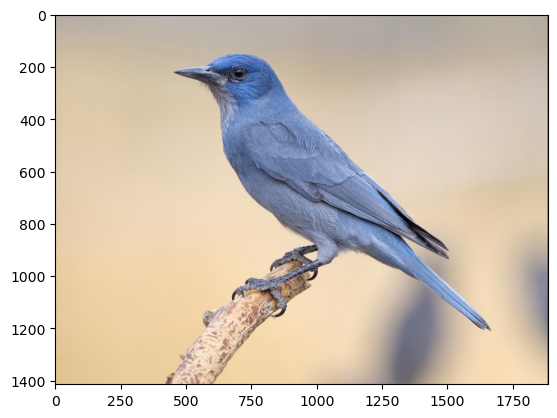

In [15]:
# !wget -nv https://static.independent.co.uk/s3fs-public/thumbnails/image/2018/04/10/19/pinyon-jay-bird.jpg -O bird.png
img = Image.open('./images/bird.jpg')
plt.imshow(img)
plt.show()

In [20]:
trf = T.Compose([T.Resize(256),
                 T.CenterCrop(224),
                 T.ToTensor(),
                 T.Normalize(mean = [0.485, 0.456, 0.406],
                             std = [0.229, 0.224, 0.225])])
inp = trf(img).unsqueeze(0)

In [21]:
inp.shape

torch.Size([1, 3, 224, 224])

T.Compose - это функция, которая принимает список, в котором каждый элемент имеет тип transforms, и возвращает объект, через который мы можем передавать партии изображений, и к ним будут применены все необходимые преобразования.

Давайте посмотрим, какие преобразования применяются к изображениям:

T.Resize(256) : Изменяет размер изображения до 256 x 256

T.CenterCrop(224) : Обрезает изображение по центру до размера 224 x 224.

T.ToTensor() : Преобразует изображение к типу torch.Tensor и значениям между [0, 1].

T.Normalize(mean, std) : Нормализует изображение с заданными средним и стандартным отклонением.

In [22]:
out = fcn(inp)['out']
print (out.shape)

torch.Size([1, 21, 224, 224])


мы получили окончательный результат модели. Как мы видим, он имеет форму [1 x 21 x H x W], как обсуждалось ранее. Итак, модель была обучена на 21 классе, и, следовательно, наш выход имеет 21 канал!

Теперь нам нужно превратить этот 21-канальный вывод в 2D-изображение или 1-канальное изображение, где каждый пиксель соответствует классу!

Итак, в 2D-изображении (форма [H x W]) каждый пиксель будет соответствовать метке класса, и таким образом
для каждого (x, y) на этом двумерном изображении будет соответствовать число от 0 до 20, обозначающее класс.

А как мы доберемся до этого [1 x 21 x H x W]?
Мы возьмем максимальный индекс для каждой позиции пикселя, который представляет класс

In [25]:
out.squeeze().shape

torch.Size([21, 224, 224])

In [ ]:
# Матрица для класса птиц
out.squeeze()[3]

tensor([[ 1.1498,  1.1498,  1.1498,  ..., -0.5075, -0.5075, -0.5075],
        [ 1.1498,  1.1498,  1.1498,  ..., -0.5075, -0.5075, -0.5075],
        [ 1.1498,  1.1498,  1.1498,  ..., -0.5075, -0.5075, -0.5075],
        ...,
        [ 0.8218,  0.8218,  0.8218,  ...,  0.8063,  0.8063,  0.8063],
        [ 0.8218,  0.8218,  0.8218,  ...,  0.8063,  0.8063,  0.8063],
        [ 0.8218,  0.8218,  0.8218,  ...,  0.8063,  0.8063,  0.8063]],
       grad_fn=<SelectBackward0>)

In [ ]:
om = torch.argmax(out.squeeze(), dim=0).detach().cpu().numpy()
print (om.shape)
# Максимальные значения пикселей для индексов классов фона и птиц
print (np.unique(om))

(224, 224)
[0 3]


In [29]:
print(om)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


теперь напишем декодер

In [42]:
# Фильтр для класса птиц
om == 3

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(224, 224))

In [43]:
def decode_segmap(image, nc=21):

  # Цветовые представления для каждого класса
  label_colors = np.array([(0, 0, 0),  # 0=background
               # 1=aeroplane, 2=bicycle, 3=bird, 4=boat, 5=bottle
               (128, 0, 0), (0, 128, 0), (128, 128, 0), (0, 0, 128), (128, 0, 128),
               # 6=bus, 7=car, 8=cat, 9=chair, 10=cow
               (0, 128, 128), (128, 128, 128), (64, 0, 0), (192, 0, 0), (64, 128, 0),
               # 11=dining table, 12=dog, 13=horse, 14=motorbike, 15=person
               (192, 128, 0), (64, 0, 128), (192, 0, 128), (64, 128, 128), (192, 128, 128),
               # 16=potted plant, 17=sheep, 18=sofa, 19=train, 20=tv/monitor
               (0, 64, 0), (128, 64, 0), (0, 192, 0), (128, 192, 0), (0, 64, 128)])

  # Подготовка черного холста из трёх каналов
  r = np.zeros_like(image).astype(np.uint8)
  g = np.zeros_like(image).astype(np.uint8)
  b = np.zeros_like(image).astype(np.uint8)

  # Перебор индексов классов
  for l in range(0, nc):
    # Маска для определения позиций в изображении для текущего класса
    idx = image == l
    # Заполнение каналов текущего класса соответствующим цветовым представлением
    r[idx] = label_colors[l, 0]
    g[idx] = label_colors[l, 1]
    b[idx] = label_colors[l, 2]

  rgb = np.stack([r, g, b], axis=2)
  return rgb

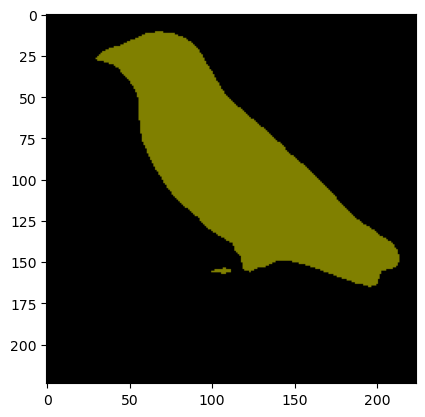

In [44]:
rgb = decode_segmap(om)
plt.imshow(rgb)
plt.show()

In [45]:
rgb.shape

(224, 224, 3)

In [46]:
# cpu, cuda, ipu, xpu, mkldnn, opengl, opencl, ideep, hip, ve, fpga, ort, xla, lazy, vulkan, mps, meta, hpu, mtia,
def segment(net, path, show_orig=True, dev='cpu'):
  img = Image.open(path)
  if show_orig: 
    plt.imshow(img)
    plt.axis('off')
    plt.show()

  trf = T.Compose([T.Resize(640),
                   #T.CenterCrop(224),
                   T.ToTensor(),
                   T.Normalize(mean = [0.485, 0.456, 0.406],
                               std = [0.229, 0.224, 0.225])])
  inp = trf(img).unsqueeze(0).to(dev)
  out = net.to(dev)(inp)['out']
  om = torch.argmax(out.squeeze(), dim=0).detach().cpu().numpy()
  rgb = decode_segmap(om)
  plt.imshow(rgb)
  plt.axis('off')
  plt.show()

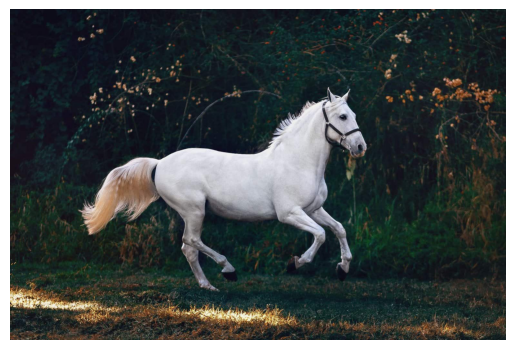

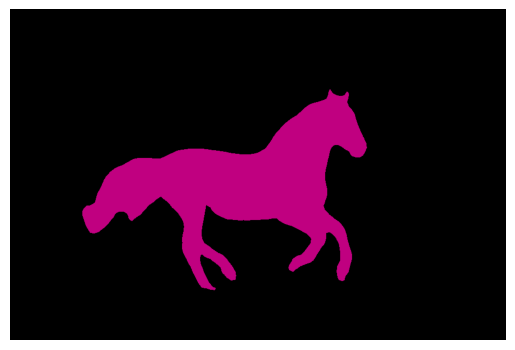

In [48]:
# !wget -nv https://www.learnopencv.com/wp-content/uploads/2021/01/horse-segmentation.jpeg -O horse.png
segment(fcn, './images/horse.jpeg')

### DeepLabv3

In [49]:
dlab = models.segmentation.deeplabv3_resnet101(pretrained=1).eval()

d:\Apps\Anaconda3\envs\otus-ml\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Apps\Anaconda3\envs\otus-ml\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to C:\Users\MazurenkoEV/.cache\torch\hub\checkpoints\deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:23<00:00, 10.5MB/s] 


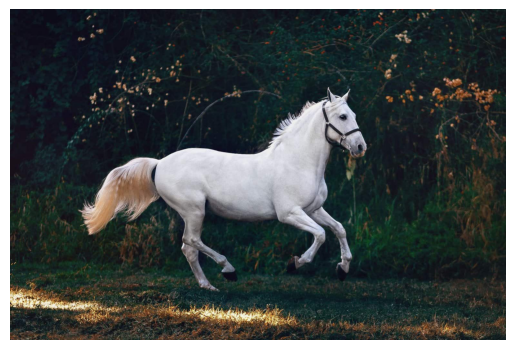

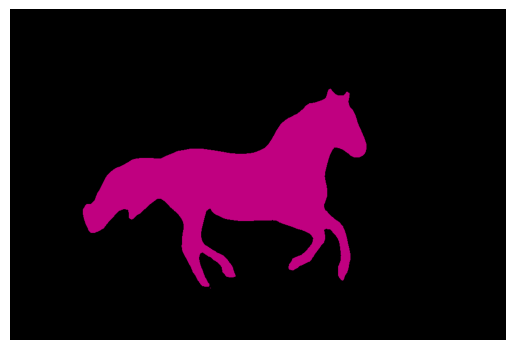

In [51]:
segment(dlab, './images/horse.jpeg')

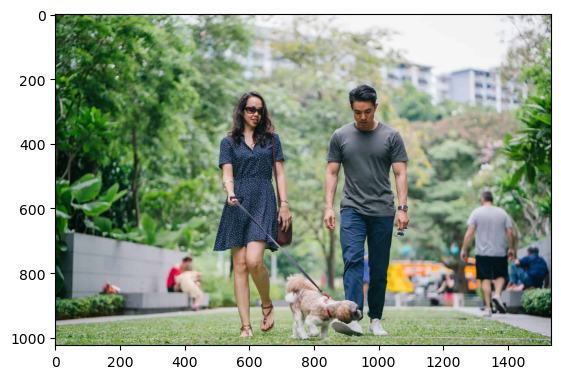

Segmenatation Image on FCN


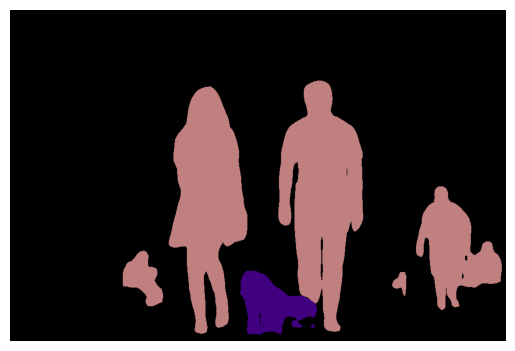

Segmenatation Image on DeepLabv3


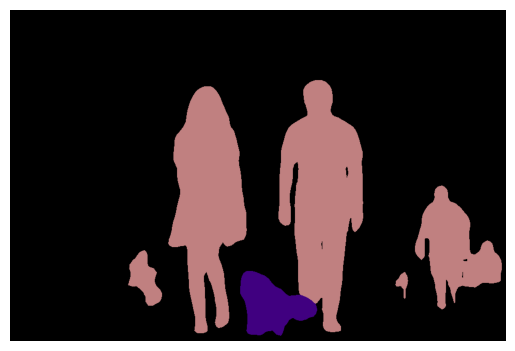

In [53]:
# !wget -nv "https://www.learnopencv.com/wp-content/uploads/2021/01/person-segmentation.jpeg" -O person.png
person_path = './images/person.jpeg'
img = Image.open(person_path)
plt.imshow(img)
plt.show()

print ('Segmenatation Image on FCN')
segment(fcn, path=person_path, show_orig=False)

print ('Segmenatation Image on DeepLabv3')
segment(dlab, path=person_path, show_orig=False)